## 🔍 Visualizing Feature-Engineered Data

Once your RANS and EXP data have been fully feature-engineered and saved (e.g., `Case2_chkpt1_full_rans_engineered.pkl`), you can quickly visualize any scalar field to inspect physical trends, alignment, or normalization effects.

### 1. Load the processed data
```python
import pandas as pd
import matplotlib.pyplot as plt

# Example: load engineered RANS data
df = pd.read_pickle("Data/Shear_mixing/MLS_u2gdu_v3/Case2_chkpt1_full_rans_engineered.pkl")
print(df.columns)  # inspect available features


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os
data_root = os.path.join(os.getcwd(), '..', 'Data')
dataset = 'Shear_mixing'
dataset_root = os.path.join(data_root, dataset)
print(dataset_root)

/Users/elliotporter/Desktop/Turb_research/Turb_PL/tutorials/../Data/Shear_mixing


In [2]:
#setup data you want to run 


#feature engineering trial
fe_name = "FE_PL_og_20251030"
case = 'Case1'
dnd = 'nondim'
fov = 'FOV1'
ckpt = 'chkpt6_train'

#load Raw Rans pregrads
Raw_Rans_path = os.path.join(dataset_root, 'EX_RANS', 'cleaned', f'{case}_pre_grads.pkl')
raw_rans = pd.read_pickle(Raw_Rans_path)
print(f"Raw Rans Features: {raw_rans.columns.to_list()}")


#Load Raw Exp pregrads
Raw_exp_path = os.path.join(dataset_root, 'EXP_ex', f'{case}_combined.pkl')
raw_exp = pd.read_pickle(Raw_exp_path)
print(f"Raw Exp Features: {raw_exp.columns.to_list()}")


#load rans FE
rans_path = os.path.join(dataset_root, fe_name, f'{case}_{ckpt}_{fov}_rans_{dnd}.pkl')
rans_df = pd.read_pickle(rans_path)
rans_path = os.path.join(dataset_root, fe_name, f'Case2_{ckpt}_{fov}_rans_{dnd}.pkl')
rans_df2 = pd.read_pickle(rans_path)
#print(f"Rans Features: {rans_df.columns.to_list()}")


#load exp FE
exp_path = os.path.join(dataset_root, fe_name, f'{case}_{ckpt}_{fov}_exp_{dnd}.pkl')
exp_df = pd.read_pickle(exp_path)
#print(f"Rans Features: {exp_df.columns.to_list()}")
rans_copy = rans_df.copy()
#exp_copy = exp_df.copy()

Raw Rans Features: ['cellID', 'Cx', 'Cy', 'Cz', 'uv', 'uu', 'vv', 'Mach', 'ww', 'p', 'rho', 'Ux', 'Uy', 'Uz', 'T', 'k', 'turb-diss-rate', 'mu_t', 'dUx_dx', 'dUy_dx', 'dUz_dx', 'dUx_dy', 'dUy_dy', 'dUz_dy', 'dUx_dz', 'dUy_dz', 'dUz_dz', 'dp_dx', 'dp_dy', 'dp_dz']
Raw Exp Features: ['U', 'V', 'W', 'V_mag', 'uu', 'vv', 'ww', 'uv', 'uuu', 'uvv', 'uww', 'vuu', 'vvv', 'vww', 'uuuu', 'vvvv', 'wwww', 'Cx', 'Cy']


In [3]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import griddata

def plot_field_comparison(
    df1, df2,
    var1='Ux', var2='U',
    t1='RANS', t2="Exp",
    fov='FOV1', case='Case2',
    cmap='jet', smooth=True, grid_res=200,
    equal_colorbar=True
):
    """
    Plot side-by-side comparison of a variable between df1 and df2 with matched axes and color scale.
    """

    plt.figure(figsize=(12,5))

    # --- Create common grid for smoother visualization ---
    if smooth:
        x = np.linspace(min(df1['Cx'].min(), df2['Cx'].min()),
                        max(df1['Cx'].max(), df2['Cx'].max()), grid_res)
        y = np.linspace(min(df1['Cy'].min(), df2['Cy'].min()),
                        max(df1['Cy'].max(), df2['Cy'].max()), grid_res)
        X, Y = np.meshgrid(x, y)
        Z_df1 = griddata((df1['Cx'], df1['Cy']), df1[var1], (X, Y), method='linear')
        Z_df2 = griddata((df2['Cx'], df2['Cy']), df2[var2], (X, Y), method='linear')
    else:
        X, Y, Z_df1, Z_df2 = df1['Cx'], df1['Cy'], df1[var1], df2[var2]

    # --- Determine shared limits ---
    xlims = (min(df1['Cx'].min(), df2['Cx'].min()), max(df1['Cx'].max(), df2['Cx'].max()))
    ylims = (min(df1['Cy'].min(), df2['Cy'].min()), max(df1['Cy'].max(), df2['Cy'].max()))

    if equal_colorbar and smooth:
        vmin = np.nanmin([Z_df1, Z_df2])
        vmax = np.nanmax([Z_df1, Z_df2])
    else:
        vmin = vmax = None

    # --- Plot T1 ---
    plt.subplot(1, 2, 1)
    plt.title(f"{case} {fov} — {t1}: {var1}")
    if smooth:
        pcm1 = plt.pcolormesh(X, Y, Z_df1, shading='auto', cmap=cmap, vmin=vmin, vmax=vmax)
    else:
        pcm1 = plt.scatter(X, Y, c=Z_df1, s=2, cmap=cmap)
    plt.colorbar(pcm1, label=var1)
    plt.xlabel("Cx [m]")
    plt.ylabel("Cy [m]")
    plt.xlim(*xlims)
    plt.ylim(*ylims)

    # --- Plot T2 ---
    plt.subplot(1, 2, 2)
    plt.title(f"{case} {fov} — {t2}: {var2}")
    if smooth:
        pcm2 = plt.pcolormesh(X, Y, Z_df2, shading='auto', cmap=cmap, vmin=vmin, vmax=vmax)
    else:
        pcm2 = plt.scatter(X, Y, c=Z_df2, s=2, cmap=cmap)
    plt.colorbar(pcm2, label=var2)
    plt.xlabel("Cx [m]")
    plt.ylabel("Cy [m]")
    plt.xlim(*xlims)
    plt.ylim(*ylims)

    plt.tight_layout()
    plt.show()

def plot_feature(df, var='Ux', t='Rans', fov='FOV1', case='Case1', cmap='jet', smooth=True, grid=200, shading='auto'):
    plt.figure(figsize=(12, 5))
    if smooth:
        X = np.linspace(df['Cx'].min(),df['Cx'].max(), grid)
        Y = np.linspace(df['Cy'].min(),df['Cy'].max(), grid)
        x, y = np.meshgrid(X,Y)
        z = griddata((df['Cx'], df['Cy']), df[var], (x, y), method='linear')
    else:
        x, y = df['Cx'], df['Cy']
        z = df[var]
    # --- Determine shared limits ---
    xlims = (df['Cx'].min(), df['Cx'].max())
    ylims = (df['Cy'].min(),df['Cy'].max())

    if smooth:
        vmin = np.nanmin([z])
        vmax = np.nanmax([z])
    else:
        vmin = vmax = None
    if smooth:
        pcm = plt.pcolormesh(x, y, z, shading=shading, cmap=cmap, vmin=vmin, vmax=vmax)
    else:
        pcm = plt.scatter(x, y, c=z, s=2, cmap=cmap)
    plt.colorbar(pcm, label=var)
    plt.xlabel("Cx [m]")
    plt.ylabel("Cy [m]")
    plt.xlim(*xlims)
    plt.ylim(*ylims)
    plt.tight_layout()
    plt.show()
    

In [4]:
print(raw_exp['Cx'].head())

0    0.240671
1    0.241026
2    0.241381
3    0.241737
4    0.242092
Name: Cx, dtype: float64


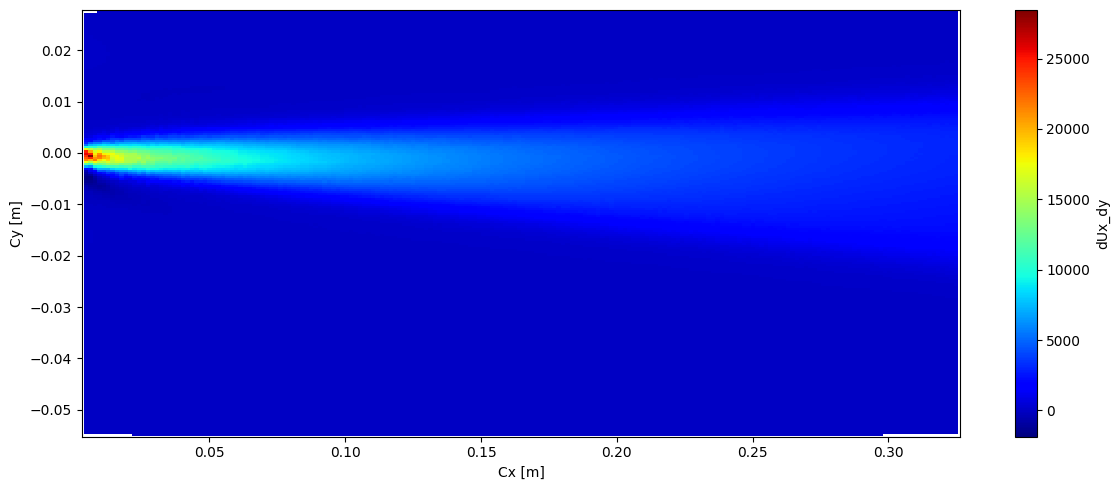

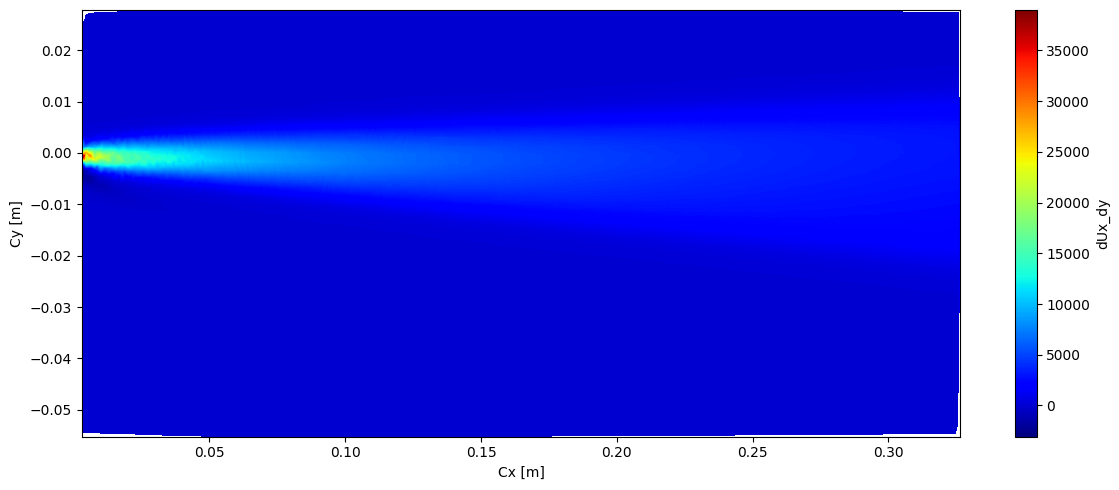

In [21]:
#clean Raw real quick
r_rans = raw_rans.copy()
xb, yb = (raw_exp['Cx'].min(), raw_exp['Cx'].max()), (raw_exp['Cy'].min(), raw_exp['Cy'].max())
mask = (r_rans['Cx'] >= xb[0]) & (r_rans['Cx'] <= xb[1]) & (r_rans['Cy'] >= yb[0]) & (r_rans['Cy'] <= yb[1])
rans = r_rans.loc[mask].reset_index(drop=True)

var= 'dUx_dy'
plot_feature(rans,var, 'RANS', 'Full', 'Case1', cmap='jet', smooth=True, grid=200, shading='auto')
plot_feature(rans,var, 'RANS', 'Full', 'Case1', cmap='jet', smooth=True, grid=2000, shading='auto')

